<a href="https://colab.research.google.com/github/khushboo2005-k/sales-insights-analytics-project/blob/main/syntecxhub_task1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import zipfile
import os

zip_file = "/content/archive.zip"  # 👈 change this to your zip name

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Extracted files:", os.listdir("dataset"))

Extracted files: ['Sample - Superstore.csv']


In [ ]:
df = pd.read_csv("dataset/Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Data Cleaning

In [ ]:
df.isnull().sum()
df = df.dropna()

# Create Revenue Column

In [ ]:
df['Revenue'] = df['Sales']

# Total Revenue

In [ ]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 2297200.8603000003


# Total Orders

In [ ]:
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 5009


# Average Order Value

In [ ]:
aov = total_revenue / total_orders
print("Average Order Value:", aov)

Average Order Value: 458.61466566180883


# Top Products

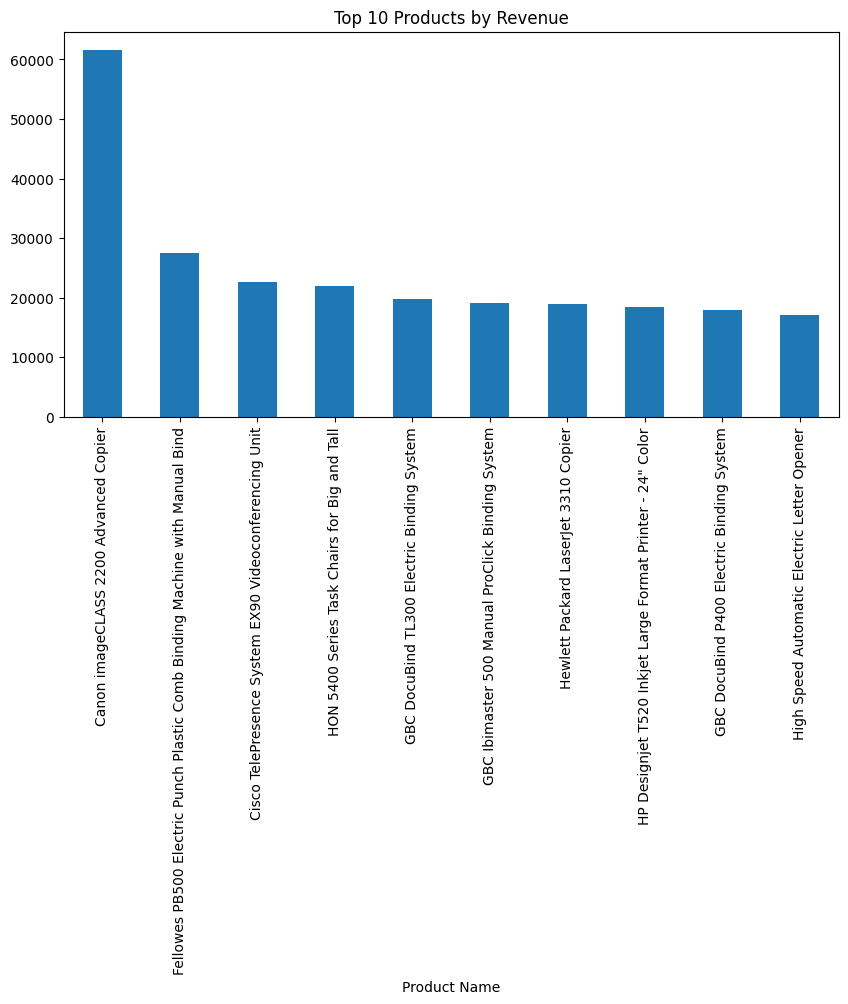

In [ ]:
top_products = df.groupby('Product Name')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.show()

# Top Regions

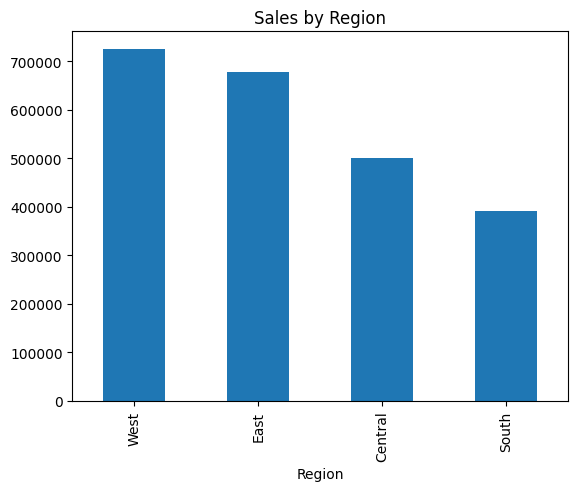

In [ ]:
top_regions = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

top_regions.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

# Monthly Sales Trend (Seasonality)

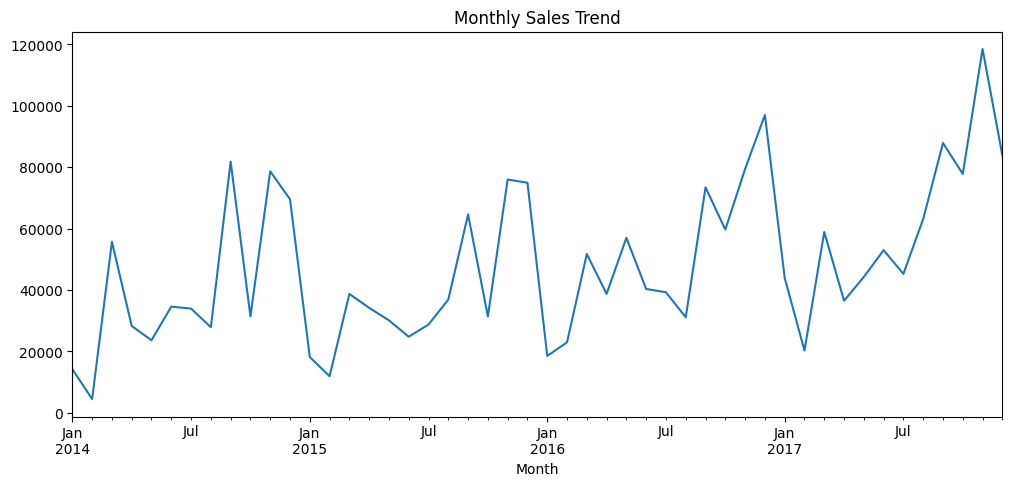

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

# Category Analysis

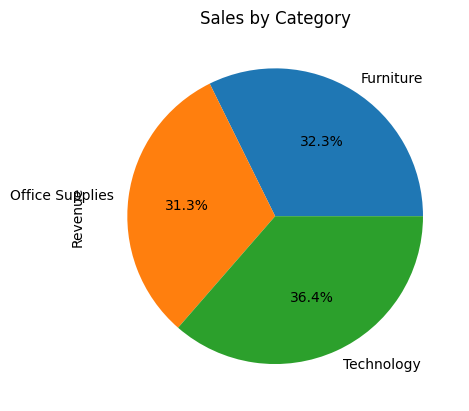

In [ ]:
category_sales = df.groupby('Category')['Revenue'].sum()

category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Category")
plt.show()